Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Import and Load datasets



In [2]:
df = pd.read_csv('dirty_cafe_sales.csv')
df.duplicated().sum()
df.head()





,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Handle missing Values(WRONG INPUT DATASETS)

In [3]:
df['Transaction ID'].value_counts()
df['Item'].value_counts()
df['Item'].replace(['UNKNOWN','ERROR'],np.nan,inplace=True)
df['Quantity'].value_counts()
df['Quantity'].replace(['UNKNOWN','ERROR'],np.nan, inplace=True)
df['Price Per Unit'].value_counts()
df['Price Per Unit'].replace(['UNKNOWN','ERROR'],np.nan,inplace=True)
df['Price Per Unit'].value_counts()
df['Total Spent'].replace(['ERROR','UNKNOWN'],np.nan, inplace=True)
df['Total Spent']=df['Total Spent'].astype(float)
df['Price Per Unit']=df['Price Per Unit'].astype(float)
df['Quantity']=df['Quantity'].astype(float)

df['Payment Method'].replace(['ERROR','UNKNOWN'],np.nan,inplace=True)
df['Location'].value_counts()
df['Location'].replace(['ERROR','UNKNOWN'],np.nan, inplace=True)
df['Location'].value_counts()
df['Transaction Date'].replace(['UNKNOWN','ERROR'],np.nan,inplace=True)
df['Payment Method'].value_counts()
df.head()


C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18716\1508962103.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].replace(['UNKNOWN','ERROR'],np.nan,inplace=True)
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18716\1508962103.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


correct the datatypes

In [4]:
df['Transaction Date']=df['Transaction Date'].astype('datetime64[ns]')
df['Quantity']=df['Quantity'].astype('Int64')
df['Quantity'].value_counts()
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


handle missing values


In [5]:
df['Transaction ID'].isna().sum()
df['Item'].fillna(method='ffill',inplace=True)
df['Quantity'].fillna(int(df['Quantity'].mean()),inplace=True)
standard_prices = {
    "Coffee": 2.0,
    "Juice": 3.0,
    "Sandwich": 4.0,
    "Cake": 3.0,
    "Salad": 5.0,
    "Smoothie": 4.0,
    "Tea": 1.5,
    "Cookie": 1.0
}

df["Price Per Unit"] = df["Item"].map(standard_prices)
df['Total Spent']=df['Price Per Unit']*df['Quantity']
df['Payment Method'].fillna(method='bfill',inplace=True)
df['Transaction Date'].fillna(method='bfill',inplace=True)
df['Location'].fillna(method='bfill',inplace=True)
df.isna().sum()
df['Location'].value_counts()




C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18716\2771446944.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].fillna(method='ffill',inplace=True)
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18716\2771446944.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Item'].fillna(method='ffill',inplace=True)
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_18716\2771446944.py:3: FutureWarning: A value is trying to be set on a

Location
Takeaway    5049
In-store    4951
Name: count, dtype: int64

dataset description


In [6]:
df.isna().sum()
df['Item'].value_counts(), df['Price Per Unit'].value_counts()
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,In-store,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Detect and address outliers

In [7]:
for col in ['Quantity','Price Per Unit', 'Total Spent']:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr

  outliers=((df[col]<lower)| (df[col]>upper)).sum()
  print(f"{col}:{outliers}")

Quantity:0
Price Per Unit:0
Total Spent:255


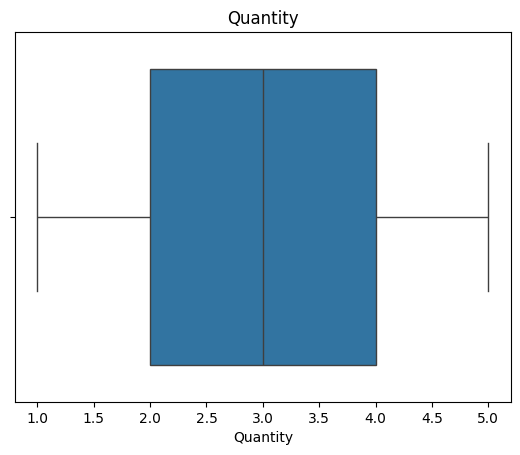

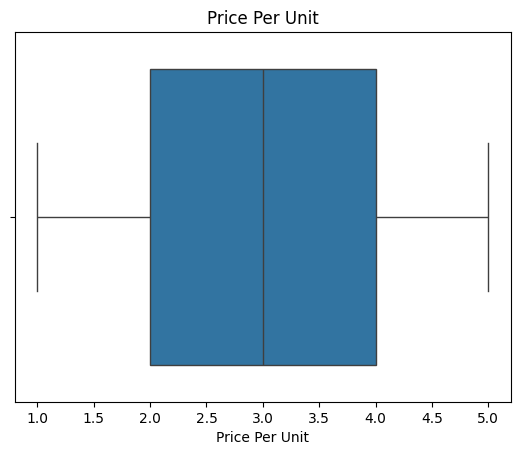

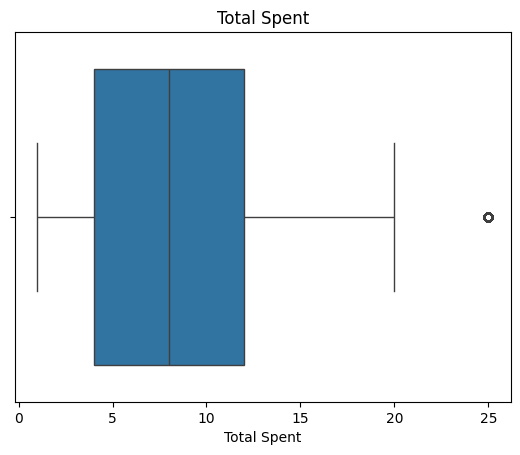

In [8]:
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()

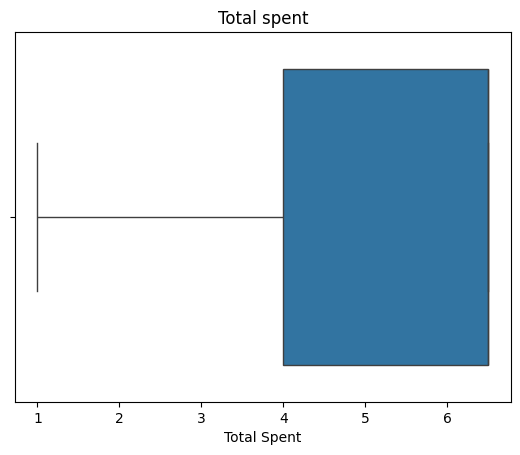

In [9]:
Q1=df['Total Spent'].quantile(0.25)
Q3=df['Total Spent'].quantile(0.35)
IQR=Q3-Q1
LOWER=Q1-1.5*IQR
UPPER=Q3+1.5*IQR

df['Total Spent']=np.where(df['Total Spent']>UPPER,UPPER,df['Total Spent'])

## confirm no outliers
sns.boxplot(x=df['Total Spent'])
plt.title('Total spent')
plt.show()



produce the cleaned dataset


In [10]:
df.to_csv('Clean_Cafe_Sales.csv')